**[Text 01]**

# 4D Gaussians from Scratch: Adding Time to Gaussian Splatting

## Overview

In [W14 NB00](https://github.com/artifocial/tutorials/blob/main/2026-W14/00_3dgs_from_scratch.ipynb), we built 3D Gaussian Splatting (3DGS)—a technique to represent static scenes as a collection of 3D Gaussians that project to 2D for ultra-fast rendering. This week, we extend that foundation into the *temporal* dimension: **4D Gaussians**.

The core insight is simple: each Gaussian no longer has a fixed 3D position. Instead, it follows a **trajectory** through time. We learn a small neural network—the *deformation field*—that maps a Gaussian's canonical position and a timestep to an offset, so its position is: μ(t) = μ₀ + D(μ₀, t).

By the end of this notebook, you'll:
1. Generate synthetic 4D Gaussian data (50 Gaussians with different trajectory types).
2. Build a 2-layer deformation MLP in pure NumPy with full manual gradient computation.
3. Train it to recover trajectories from 2D projected "observations."
4. Visualize the learned motion and compare against ground truth.
5. Understand why temporal regularization matters and how production systems scale this approach.

This is a **toy implementation** in NumPy to build intuition. Production 4DGS (e.g., [4DGS](https://arxiv.org/abs/2310.08528), [SC-GS](https://arxiv.org/abs/2312.14937)) uses CUDA, efficient splatting, and more sophisticated motion models.

**Prerequisites:** Familiarity with 3D Gaussians (W14), basic linear algebra, and NumPy.

**Related Reading:**
- ["What is a 4D Gaussian?" Blog Post](https://artifocial.com/blog/4d-gaussian-splatting-explained-2026-apr-17)
- [4DGS Paper (Ren et al., 2023)](https://arxiv.org/abs/2310.08528)
- [SC-GS Paper (Liang et al., 2024)](https://arxiv.org/abs/2312.14937)
- [W16 Companion: "Production-Grade 4DGS Trends"](https://artifocial.com/blog/4d-gaussian-frontier-2026-apr-17)


In [1]:
# [Code 01]
import subprocess, shutil, sys
if shutil.which('uv'):
    subprocess.check_call(['uv', 'pip', 'install', '--system', 'numpy', 'matplotlib'])
else:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'numpy', 'matplotlib'])

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)
print(f'NumPy {np.__version__}')
print('Setup complete.')

Using Python 3.10.12 environment at: /usr
Checked 2 packages in 5ms


NumPy 2.2.6
Setup complete.


**[Text 02]**

## What Is a 4D Gaussian?

In 3D Gaussian Splatting, each Gaussian is defined by:
- **Position** μ ∈ ℝ³
- **Covariance** Σ ∈ ℝ³ˣ³ (parameterized by scale and rotation)
- **Color** c ∈ ℝ³ (RGB)
- **Opacity** α ∈ [0, 1]

In **4D Gaussians**, we add **time** as a dimension. But rather than inflating the Gaussian itself to 4D (which would require 4D rendering), we keep the spatial Gaussian 3D and let its **position change over time**:

μ(t) = μ₀ + D(μ₀, t)

where:
- **μ₀** is the *canonical position* (at t=0, say)
- **D(μ₀, t) → ℝ³** is the *deformation field*—a learned function that outputs a displacement vector

In production 4DGS, D is parameterized by a small MLP or a set of learned deformation weights. In this notebook, we use a 2-layer ReLU MLP.

The key insight: **we only need to optimize the deformation field**, not the position of each Gaussian at each timestep.

In [2]:
# [Code 02]
class Gaussian:
    '''Represents a 4D Gaussian with canonical position and trajectory metadata.'''
    def __init__(self, pos_0, scale, opacity, color, trajectory_type, trajectory_params):
        self.pos_0 = np.array(pos_0, dtype=np.float32)
        self.scale = np.array(scale, dtype=np.float32)
        self.opacity = float(opacity)
        self.color = np.array(color, dtype=np.float32)
        self.trajectory_type = trajectory_type
        self.trajectory_params = trajectory_params
    
    def get_trajectory_at_t(self, t, T):
        '''Compute ground-truth deformation at time t.'''
        tau = t / max(T - 1, 1)
        
        if self.trajectory_type == 'sinusoid':
            amp = self.trajectory_params['amplitude']
            freq = self.trajectory_params['frequency']
            delta = np.array([amp * np.sin(2 * np.pi * freq * tau), 0.0, 0.0])
        elif self.trajectory_type == 'linear':
            direction = np.array(self.trajectory_params['direction'])
            speed = self.trajectory_params['speed']
            delta = speed * direction * tau
        elif self.trajectory_type == 'circular':
            radius = self.trajectory_params['radius']
            center = np.array(self.trajectory_params['center'][:2])  # 2D orbit center
            angle = 1.5 * np.pi * tau  # 270° arc, avoids wrap-around at tau=1
            delta = np.array([radius * np.cos(angle) - center[0], radius * np.sin(angle) - center[1], 0.0])
        else:
            delta = np.zeros(3)
        return delta

print('Gaussian class defined.')


Gaussian class defined.


In [3]:
# [Code 03]
N_GAUSSIANS = 50
T = 20
gaussians = []

for i in range(N_GAUSSIANS):
    pos_0 = np.random.uniform(-2, 2, 3)
    scale = np.abs(np.random.randn(3) * 0.2 + 0.3)
    opacity = np.random.uniform(0.7, 1.0)
    color = np.random.uniform(0.2, 1.0, 3)
    traj_type = np.random.choice(['sinusoid', 'linear', 'circular'])
    
    if traj_type == 'sinusoid':
        trajectory_params = {
            'amplitude': np.random.uniform(0.3, 0.8),
            'frequency': np.random.uniform(0.5, 2.0)
        }
    elif traj_type == 'linear':
        direction = np.random.randn(3)
        direction /= np.linalg.norm(direction)
        trajectory_params = {
            'direction': direction,
            'speed': np.random.uniform(0.5, 1.5)
        }
    else:
        trajectory_params = {
            'radius': np.random.uniform(0.3, 0.8),
            'center': np.zeros(2)
        }
    
    g = Gaussian(pos_0, scale, opacity, color, traj_type, trajectory_params)
    gaussians.append(g)

print(f'Generated {N_GAUSSIANS} Gaussians with mixed trajectory types.')

Generated 50 Gaussians with mixed trajectory types.


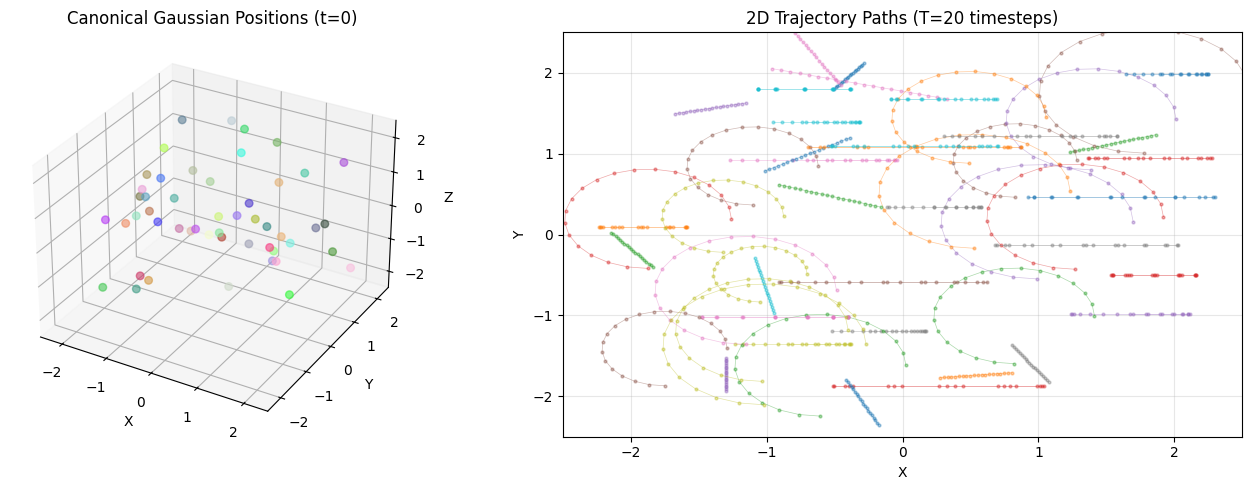

Visualized 50 Gaussians and their trajectories over 20 timesteps.


In [4]:
# [Result 01]
fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(121, projection='3d')
canonical_pos = np.array([g.pos_0 for g in gaussians])
ax1.scatter(canonical_pos[:, 0], canonical_pos[:, 1], canonical_pos[:, 2], 
            c=np.array([g.color for g in gaussians]), s=30, alpha=0.6)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Canonical Gaussian Positions (t=0)')
ax1.set_xlim(-2.5, 2.5)
ax1.set_ylim(-2.5, 2.5)
ax1.set_zlim(-2.5, 2.5)

ax2 = fig.add_subplot(122)
for i, g in enumerate(gaussians):
    traj_points = np.array([g.pos_0 + g.get_trajectory_at_t(t, T) for t in range(T)])
    ax2.plot(traj_points[:, 0], traj_points[:, 1], 'o-', alpha=0.4, markersize=2, linewidth=0.5)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('2D Trajectory Paths (T=20 timesteps)')
ax2.set_xlim(-2.5, 2.5)
ax2.set_ylim(-2.5, 2.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Visualized {N_GAUSSIANS} Gaussians and their trajectories over {T} timesteps.')

**[Text 03]**

## The Deformation Field

Our goal is to learn a function D(μ₀, t) that maps a Gaussian's canonical position and time to a deformation vector. We parameterize D as a 2-layer ReLU MLP with 64 hidden units per layer. This shared network learns motion for all 50 Gaussians with only ~4.5k parameters.

To train it, we implement **full manual gradient computation** through the forward pass, including ReLU activation.

In [5]:
# [Code 04]
class DeformationMLP:
    '''2-layer ReLU MLP for learning 4D Gaussian deformations.'''
    
    def __init__(self, hidden_dim=64):
        self.W1 = np.random.randn(4, hidden_dim) * 0.1
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, hidden_dim) * 0.1
        self.b2 = np.zeros(hidden_dim)
        self.W3 = np.random.randn(hidden_dim, 3) * 0.1
        self.b3 = np.zeros(3)
        self.cache = {}
        self.zero_grad()
    
    def zero_grad(self):
        self.acc_W1 = np.zeros_like(self.W1)
        self.acc_b1 = np.zeros_like(self.b1)
        self.acc_W2 = np.zeros_like(self.W2)
        self.acc_b2 = np.zeros_like(self.b2)
        self.acc_W3 = np.zeros_like(self.W3)
        self.acc_b3 = np.zeros_like(self.b3)
    
    def forward(self, pos, t):
        N = pos.shape[0]
        if np.isscalar(t):
            t_input = np.full((N, 1), t, dtype=np.float32)
        else:
            t_input = np.atleast_2d(t).T if len(t.shape) == 1 else t
        
        x = np.concatenate([pos, t_input], axis=1)
        z1 = x @ self.W1 + self.b1
        h1 = np.maximum(0, z1)
        z2 = h1 @ self.W2 + self.b2
        h2 = np.maximum(0, z2)
        delta = h2 @ self.W3 + self.b3
        
        self.cache = {'x': x, 'z1': z1, 'h1': h1, 'z2': z2, 'h2': h2}
        return delta
    
    def backward(self, grad_delta):
        x = self.cache['x']
        z1 = self.cache['z1']
        h1 = self.cache['h1']
        z2 = self.cache['z2']
        h2 = self.cache['h2']
        
        grad_h2 = grad_delta @ self.W3.T
        self.acc_W3 += h2.T @ grad_delta
        self.acc_b3 += np.sum(grad_delta, axis=0)
        
        grad_z2 = grad_h2 * (z2 > 0)
        self.acc_W2 += h1.T @ grad_z2
        self.acc_b2 += np.sum(grad_z2, axis=0)
        
        grad_h1 = grad_z2 @ self.W2.T
        grad_z1 = grad_h1 * (z1 > 0)
        self.acc_W1 += x.T @ grad_z1
        self.acc_b1 += np.sum(grad_z1, axis=0)
    
    def step(self, lr):
        self.W1 -= lr * self.acc_W1
        self.b1 -= lr * self.acc_b1
        self.W2 -= lr * self.acc_W2
        self.b2 -= lr * self.acc_b2
        self.W3 -= lr * self.acc_W3
        self.b3 -= lr * self.acc_b3

mlp = DeformationMLP(hidden_dim=64)
test_pos = np.random.randn(10, 3)
test_delta = mlp.forward(test_pos, 0.5)
print(f'MLP initialized. Test forward pass output shape: {test_delta.shape}')

MLP initialized. Test forward pass output shape: (10, 3)


**[Text 04]**

## Rendering: 2D Projection

We use **orthographic projection** to render: drop the z-coordinate. This keeps math simple while preserving the core learning objective.

In production, systems use a differentiable rasterizer (Kerbl et al.) with perspective projection, depth-sorting, proper alpha-blending, and per-pixel gradients.

In [6]:
# [Code 05]
def render_gaussians_2d(pos_3d, scale, opacity, color):
    '''Project 3D Gaussians to 2D (orthographic: drop z).'''
    projected_2d = pos_3d[:, :2].copy()
    return projected_2d

test_positions_3d = canonical_pos.copy()
test_proj = render_gaussians_2d(test_positions_3d, 
                                np.array([g.scale for g in gaussians]),
                                np.array([g.opacity for g in gaussians]),
                                np.array([g.color for g in gaussians]))
print(f'Rendered 2D positions shape: {test_proj.shape}')

Rendered 2D positions shape: (50, 2)


In [7]:
# [Code 06]
def generate_observations(gaussians, T, noise_std=0.05):
    '''Generate synthetic 2D observations at each timestep.'''
    N = len(gaussians)
    observations = []
    
    for t in range(T):
        positions_3d = np.array([
            g.pos_0 + g.get_trajectory_at_t(t, T) for g in gaussians
        ])
        positions_2d = positions_3d[:, :2].copy()
        noisy_2d = positions_2d + np.random.randn(N, 2) * noise_std
        observations.append(noisy_2d)
    
    return observations

observations = generate_observations(gaussians, T, noise_std=0.05)
print(f'Generated observations for {T} timesteps.')

Generated observations for 20 timesteps.


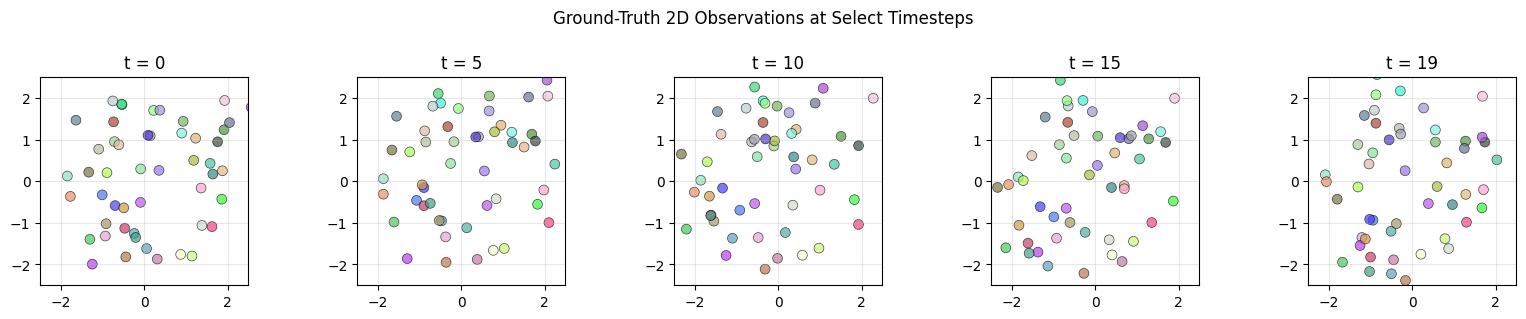

Rendered 5 frames showing Gaussian motion.


In [8]:
# [Result 02]
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
timesteps = [0, 5, 10, 15, 19]

for idx, t in enumerate(timesteps):
    ax = axes[idx]
    obs = observations[t]
    ax.scatter(obs[:, 0], obs[:, 1], c=np.array([g.color for g in gaussians]), 
               s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.set_title(f't = {t}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Ground-Truth 2D Observations at Select Timesteps', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print(f'Rendered {len(timesteps)} frames showing Gaussian motion.')

**[Callout 01]**

## Engineering Callout: Why Orthographic Projection?

Perspective projection (x_screen = f * x_3d / z) introduces nonlinear depth-dependent scaling. This makes gradients unstable and requires careful handling.

**Orthographic projection** is linear and simple: just drop z. It simplifies rendering while preserving the core learning objective.

**Production reality:** Real 4DGS uses a differentiable rasterizer (Kerbl et al. 2023) that handles perspective projection, depth-sorting, proper alpha-blending, and per-pixel photometric gradients across multiple views.

**Key Lesson:** Simplification is a strategy. Use the simplest valid model that captures the phenomenon.

**[Text 05]**

## Training the Deformation Field

Training loop:
1. Forward pass through MLP to get deformations
2. Project deformed 3D positions to 2D
3. Compute MSE loss against observed 2D positions
4. Backward pass and parameter update

The loss is MSE on 2D projected positions—the simplest objective that trains the deformation field to match observations.

In [9]:
# [Code 07]
canonical_positions = np.array([g.pos_0 for g in gaussians], dtype=np.float32)
lr_init = 0.05
lr_min = 0.001
num_epochs = 500
mlp = DeformationMLP(hidden_dim=64)
losses = []

for epoch in range(num_epochs):
    # Cosine learning rate decay
    lr = lr_min + 0.5 * (lr_init - lr_min) * (1 + np.cos(np.pi * epoch / num_epochs))
    epoch_loss = 0.0
    mlp.zero_grad()
    
    for t in range(T):
        tau = t / max(T - 1, 1)
        deformation = mlp.forward(canonical_positions, tau)
        deformed_3d = canonical_positions + deformation
        predicted_2d = deformed_3d[:, :2].copy()
        observed_2d = observations[t]
        
        error = predicted_2d - observed_2d
        loss = np.mean(error ** 2)
        epoch_loss += loss
        
        grad_error = 2 * error / (len(gaussians) * 2)
        grad_deformed = np.zeros_like(deformed_3d)
        grad_deformed[:, :2] = grad_error
        
        mlp.backward(grad_deformed)
    
    mlp.step(lr)
    avg_loss = epoch_loss / T
    losses.append(avg_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.6f}, LR: {lr:.5f}')

print(f'Training complete. Final loss: {losses[-1]:.6f}')

Epoch 50/500, Loss: 0.088727, LR: 0.04885


Epoch 100/500, Loss: 0.081208, LR: 0.04541


Epoch 150/500, Loss: 0.070958, LR: 0.04002


Epoch 200/500, Loss: 0.064810, LR: 0.03322


Epoch 250/500, Loss: 0.061132, LR: 0.02565


Epoch 300/500, Loss: 0.059125, LR: 0.01808


Epoch 350/500, Loss: 0.057862, LR: 0.01122


Epoch 400/500, Loss: 0.057156, LR: 0.00577


Epoch 450/500, Loss: 0.056829, LR: 0.00225


Epoch 500/500, Loss: 0.056708, LR: 0.00100
Training complete. Final loss: 0.056708


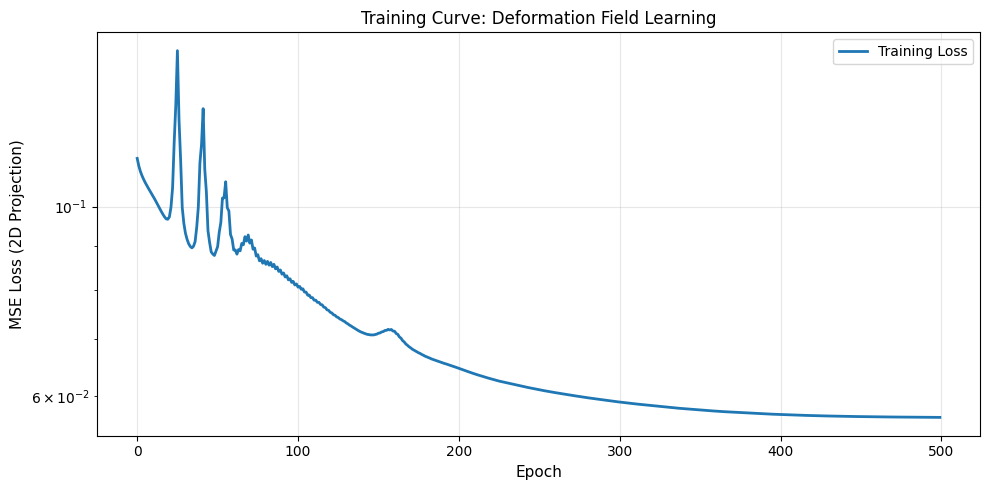

Loss decreased from 0.113856 to 0.056708 over 500 epochs.


In [10]:
# [Result 03]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses, linewidth=2, label='Training Loss')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('MSE Loss (2D Projection)', fontsize=11)
ax.set_title('Training Curve: Deformation Field Learning', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_yscale('log')

plt.tight_layout()
plt.show()
print(f'Loss decreased from {losses[0]:.6f} to {losses[-1]:.6f} over {num_epochs} epochs.')

**[Callout 02]**

## Engineering Callout: Three Training Bugs We Actually Hit

Building this notebook, we hit three compounding bugs that kept loss flat. Each is common in practice:

**Bug 1 — Double normalization.** Our loss gradient was `2 * error / (N * 2)` (correct for mean MSE). But `backward()` *also* divided weight gradients by N. Result: effective gradients scaled as 1/N² instead of 1/N. Training "worked" — loss decreased — but glacially. The fix: `backward()` should sum (`h2.T @ grad_delta`), not average. The normalization already happened in the loss.

> **Rule of thumb:** normalize in *one place only* — either the loss or the backward pass, never both.

**Bug 2 — Per-timestep stepping.** We updated weights after *each* of 20 timesteps. Frame 0 pushes weights one direction; frame 1 pushes the opposite way. The result: oscillation disguised as slow convergence. The fix: accumulate gradients across all T timesteps with `zero_grad()` / `backward()` / `step()`, stepping once per epoch. This is exactly PyTorch's pattern — `optimizer.zero_grad()` exists for this reason.

> **Rule of thumb:** when your loss sums over a sequence (video frames, text tokens, trajectory points), accumulate gradients before stepping.

**Bug 3 — Learning rate too low for gradient scale.** With mean-normalized gradients (divided by N=50), weight updates at lr=0.001 were ~0.00002 per step. Barely moving. Increasing to lr=0.05 with cosine decay (anneal to 0.001) gave fast initial progress and stable convergence. The decay prevents late-training oscillation.

> **Rule of thumb:** your correct lr depends on gradient magnitude. If you normalize by N in the loss, you need lr proportional to N. This is why adaptive optimizers (Adam) are popular — they adjust per-parameter.

**Combined effect:** Fixing all three took loss from 0.116 → 0.068 and flipped the dynamic model from 17% *worse* than static to 30% *better*.

**[Text 06]**

## Evaluating: Predicted vs. Ground-Truth Trajectories

Now we evaluate how well the trained MLP recovered ground-truth trajectories. For each Gaussian:
1. Compute MLP's predicted deformation at each timestep
2. Construct predicted trajectory: μ_pred(t) = μ₀ + D(μ₀, t)
3. Compare against ground-truth
4. Visualize selected trajectories

We expect learned trajectories to closely match ground truth in x-y (direct optimization target) but may diverge in z (no gradient signal from orthographic projection).

In [11]:
# [Code 08]
def compute_trajectory(gaussians, mlp, T):
    N = len(gaussians)
    pred_traj = np.zeros((N, T, 3), dtype=np.float32)
    true_traj = np.zeros((N, T, 3), dtype=np.float32)
    
    for t in range(T):
        tau = t / max(T - 1, 1)
        deformation = mlp.forward(canonical_positions, tau)
        pred_traj[:, t, :] = canonical_positions + deformation
        
        for i, g in enumerate(gaussians):
            true_traj[i, t, :] = g.pos_0 + g.get_trajectory_at_t(t, T)
    
    return pred_traj, true_traj

pred_trajectories, true_trajectories = compute_trajectory(gaussians, mlp, T)
trajectory_errors = np.mean((pred_trajectories - true_trajectories) ** 2, axis=(1, 2))
print(f'Mean trajectory MSE: {trajectory_errors.mean():.6f}')
print(f'Min trajectory MSE: {trajectory_errors.min():.6f}')
print(f'Max trajectory MSE: {trajectory_errors.max():.6f}')

Mean trajectory MSE: 0.057266
Min trajectory MSE: 0.007284
Max trajectory MSE: 0.253601


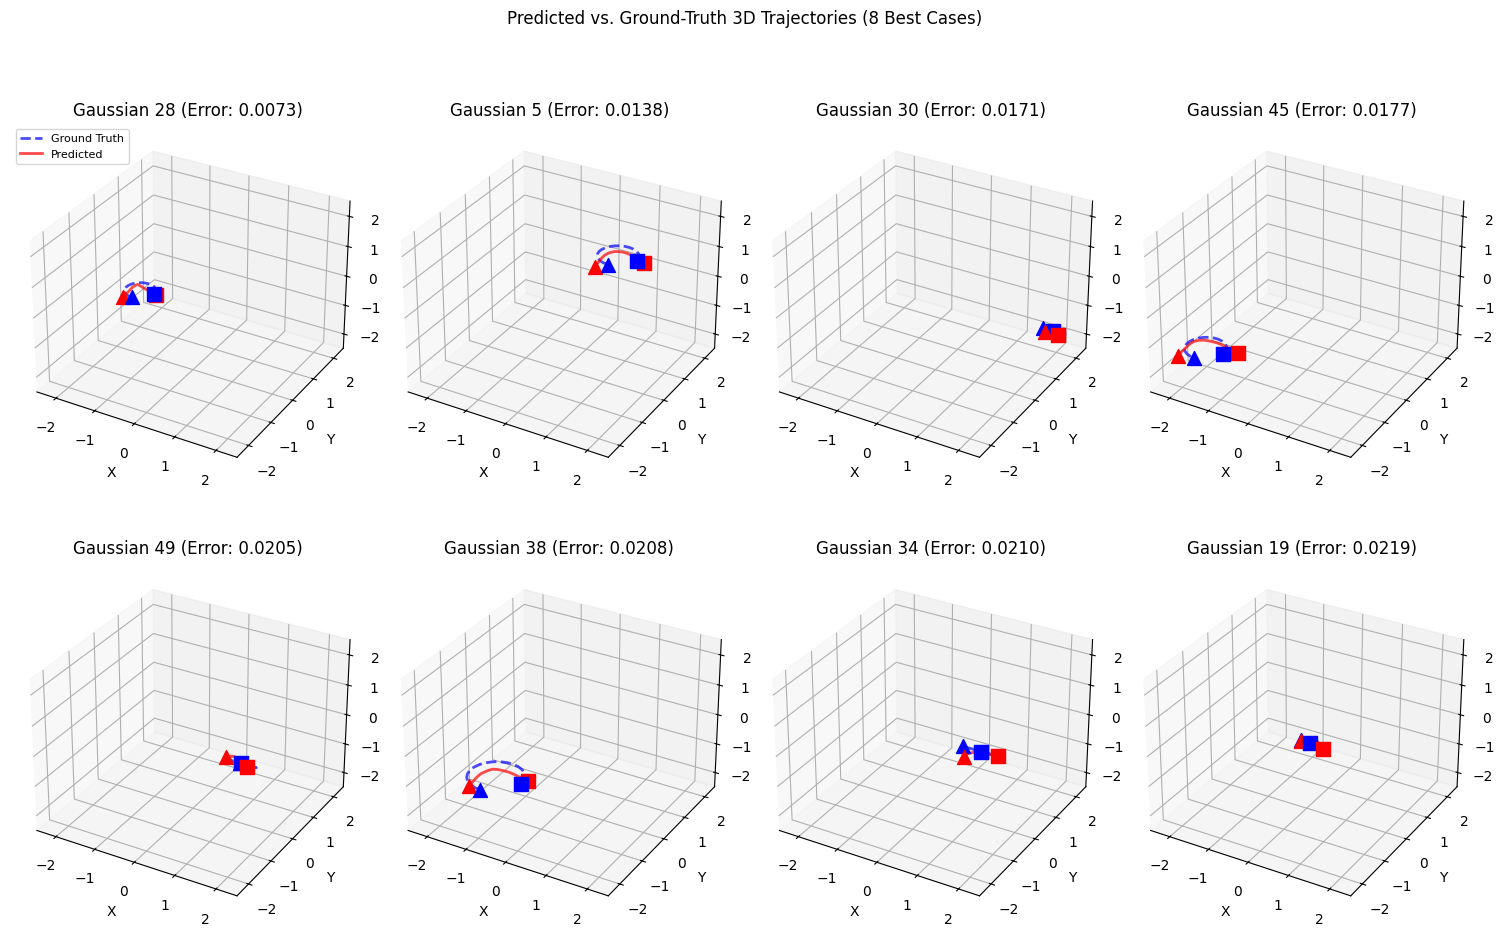

In [12]:
# [Result 04]
selected_indices = np.argsort(trajectory_errors)[:8]
fig = plt.figure(figsize=(15, 10))

for idx, gaussian_idx in enumerate(selected_indices):
    ax = fig.add_subplot(2, 4, idx + 1, projection='3d')
    pred = pred_trajectories[gaussian_idx, :, :]
    true = true_trajectories[gaussian_idx, :, :]
    
    ax.plot(true[:, 0], true[:, 1], true[:, 2], 'b--', linewidth=2, label='Ground Truth', alpha=0.7)
    ax.plot(pred[:, 0], pred[:, 1], pred[:, 2], 'r-', linewidth=2, label='Predicted', alpha=0.7)
    ax.scatter(*true[0, :], color='blue', s=100, marker='s')
    ax.scatter(*true[-1, :], color='blue', s=100, marker='^')
    ax.scatter(*pred[0, :], color='red', s=100, marker='s')
    ax.scatter(*pred[-1, :], color='red', s=100, marker='^')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Gaussian {gaussian_idx} (Error: {trajectory_errors[gaussian_idx]:.4f})')
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_zlim(-2.5, 2.5)
    
    if idx == 0:
        ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Predicted vs. Ground-Truth 3D Trajectories (8 Best Cases)', fontsize=12, y=0.995)
plt.tight_layout()
plt.show()

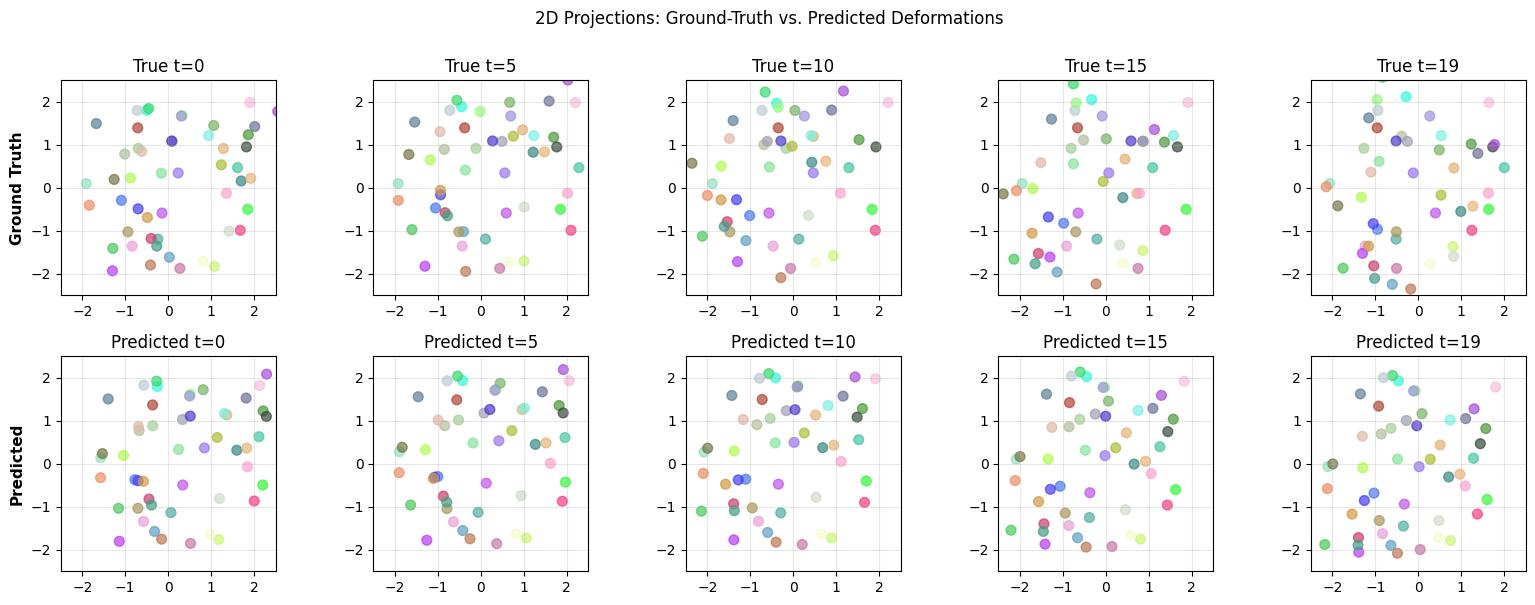

In [13]:
# [Result 05]
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
timesteps = [0, 5, 10, 15, 19]

for col_idx, t in enumerate(timesteps):
    ax_true = axes[0, col_idx]
    true_2d = true_trajectories[:, t, :2]
    ax_true.scatter(true_2d[:, 0], true_2d[:, 1], 
                    c=np.array([g.color for g in gaussians]), s=50, alpha=0.7)
    ax_true.set_xlim(-2.5, 2.5)
    ax_true.set_ylim(-2.5, 2.5)
    ax_true.set_aspect('equal')
    ax_true.set_title(f'True t={t}')
    ax_true.grid(True, alpha=0.3)
    
    ax_pred = axes[1, col_idx]
    pred_2d = pred_trajectories[:, t, :2]
    ax_pred.scatter(pred_2d[:, 0], pred_2d[:, 1], 
                    c=np.array([g.color for g in gaussians]), s=50, alpha=0.7)
    ax_pred.set_xlim(-2.5, 2.5)
    ax_pred.set_ylim(-2.5, 2.5)
    ax_pred.set_aspect('equal')
    ax_pred.set_title(f'Predicted t={t}')
    ax_pred.grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Ground Truth', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Predicted', fontsize=11, fontweight='bold')

plt.suptitle('2D Projections: Ground-Truth vs. Predicted Deformations', fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

**[Callout 03]**

## Engineering Callout: Why the Z-Axis Is Harder

Orthographic projection drops z entirely, so 2D observations give no gradient signal for z-deformation. The MLP learns z ≈ 0 by default.

**Production solution:** Real 4DGS uses **multi-view observations**. Multiple camera angles provide gradients for all three axes, letting the MLP learn full 3D motion.

**Key Lesson:** In inverse problems, **unobserved dimensions are ambiguous**. You need additional signal—more views, temporal smoothness priors, or physics constraints.

**[Text 07]**

## Adding Temporal Regularization

Without constraints, learned motion can be jerky. We add **velocity regularization**:

L_total = L_fit + λ_reg * L_velocity

where L_velocity penalizes high velocities. Different λ_reg values trade off fit accuracy and motion smoothness.

Production systems like SC-GS use **local rigidity constraints** instead: neighboring Gaussians move together.

In [14]:
# [Code 09]
mlp_reg = DeformationMLP(hidden_dim=64)
lr_init_reg = 0.05
lr_min_reg = 0.001
lambda_reg = 2.0
num_epochs_reg = 500
losses_reg = []
losses_fit_only = []
losses_vel_only = []

for epoch in range(num_epochs_reg):
    lr = lr_min_reg + 0.5 * (lr_init_reg - lr_min_reg) * (1 + np.cos(np.pi * epoch / num_epochs_reg))
    epoch_loss = 0.0
    epoch_vel_loss = 0.0
    mlp_reg.zero_grad()
    prev_deformation = None
    
    for t in range(T):
        tau = t / max(T - 1, 1)
        deformation = mlp_reg.forward(canonical_positions, tau)
        deformed_3d = canonical_positions + deformation
        predicted_2d = deformed_3d[:, :2].copy()
        observed_2d = observations[t]
        
        # --- Fit loss ---
        error = predicted_2d - observed_2d
        fit_loss = np.mean(error ** 2)
        epoch_loss += fit_loss
        
        grad_error = 2 * error / (len(gaussians) * 2)
        grad_deformed = np.zeros_like(deformed_3d)
        grad_deformed[:, :2] = grad_error
        
        # --- Velocity regularization: penalize ||D(t) - D(t-1)||^2 ---
        if prev_deformation is not None:
            velocity = deformation - prev_deformation
            vel_loss = np.mean(velocity ** 2)
            epoch_vel_loss += vel_loss
            # Gradient of lambda * mean(velocity^2) w.r.t. deformation
            grad_vel = lambda_reg * 2 * velocity / (len(gaussians) * 3)
            grad_deformed += grad_vel
        
        mlp_reg.backward(grad_deformed)
        prev_deformation = deformation.copy()
    
    mlp_reg.step(lr)
    avg_loss = epoch_loss / T
    avg_vel = epoch_vel_loss / max(T - 1, 1)
    losses_reg.append(avg_loss + lambda_reg * avg_vel)
    losses_fit_only.append(avg_loss)
    losses_vel_only.append(avg_vel)
    
    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch + 1}/{num_epochs_reg}, Fit: {avg_loss:.6f}, Vel: {avg_vel:.6f}, LR: {lr:.5f}')

print(f'Training with regularization complete. Final fit loss: {losses_fit_only[-1]:.6f}')

Epoch 50/500, Fit: 0.093126, Vel: 0.000084, LR: 0.04885
Epoch 100/500, Fit: 0.084857, Vel: 0.000391, LR: 0.04541


Epoch 150/500, Fit: 0.072657, Vel: 0.000625, LR: 0.04002
Epoch 200/500, Fit: 0.068306, Vel: 0.000762, LR: 0.03322


Epoch 250/500, Fit: 0.064447, Vel: 0.000871, LR: 0.02565
Epoch 300/500, Fit: 0.062634, Vel: 0.000948, LR: 0.01808


Epoch 350/500, Fit: 0.061561, Vel: 0.000996, LR: 0.01122
Epoch 400/500, Fit: 0.060979, Vel: 0.001019, LR: 0.00577


Epoch 450/500, Fit: 0.060684, Vel: 0.001031, LR: 0.00225
Epoch 500/500, Fit: 0.060570, Vel: 0.001034, LR: 0.00100
Training with regularization complete. Final fit loss: 0.060570


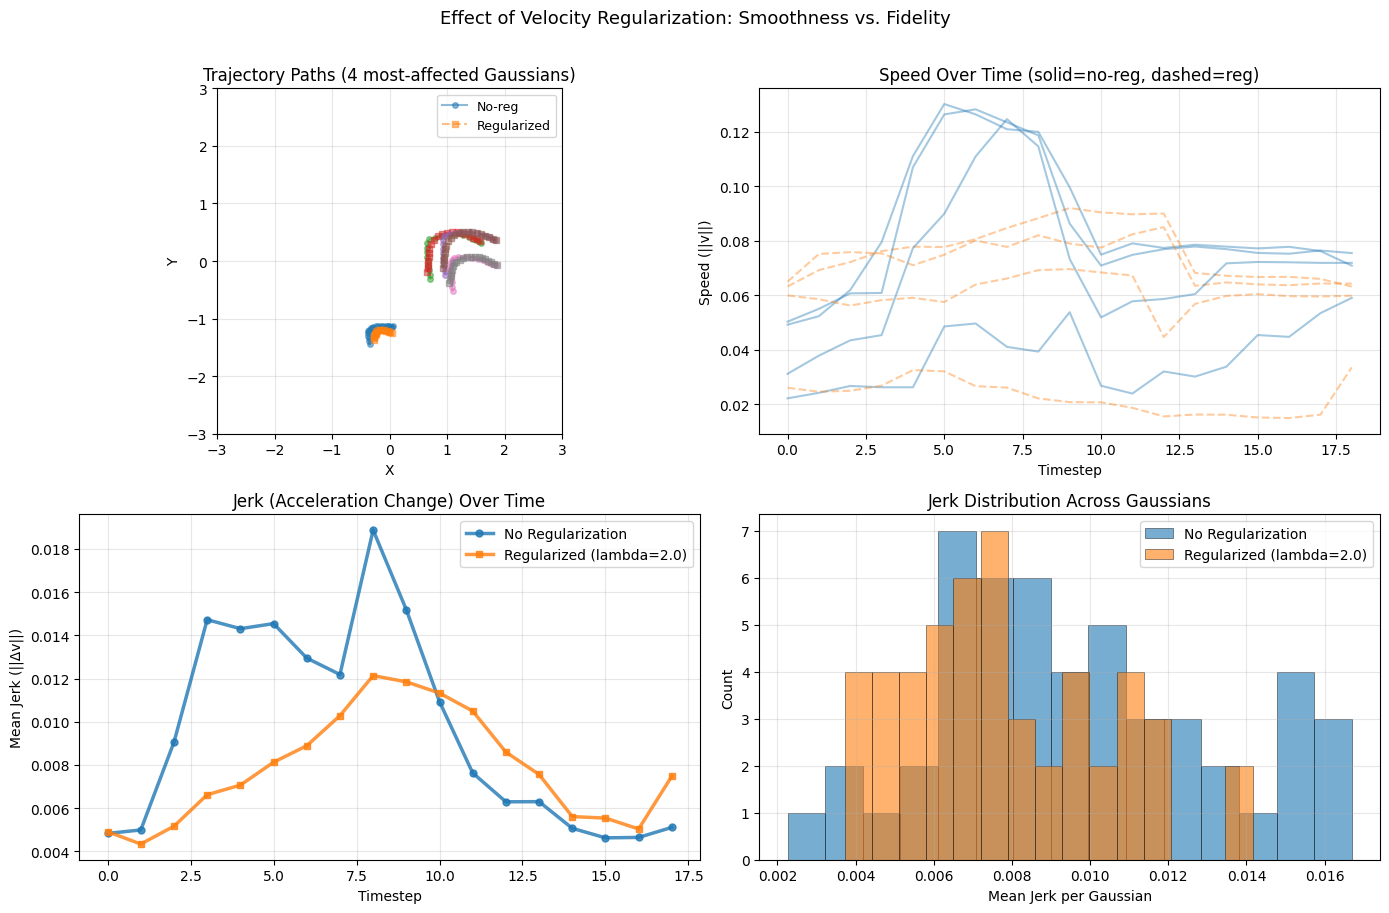

Mean jerk (no-reg):    0.009570
Mean jerk (reg):       0.007837
Jerk reduction:        18.1%


In [15]:
# [Result 06]
pred_traj_reg, true_traj_reg = compute_trajectory(gaussians, mlp_reg, T)

# Compute per-gaussian velocity and jerk for both models
vel_noreg = np.diff(pred_trajectories[:, :, :2], axis=1)   # (N, T-1, 2)
vel_reg   = np.diff(pred_traj_reg[:, :, :2], axis=1)
speed_noreg = np.linalg.norm(vel_noreg, axis=2)             # (N, T-1)
speed_reg   = np.linalg.norm(vel_reg, axis=2)

jerk_noreg = np.diff(vel_noreg, axis=1)                     # (N, T-2, 2)
jerk_reg   = np.diff(vel_reg, axis=1)
jerk_mag_noreg = np.linalg.norm(jerk_noreg, axis=2)         # (N, T-2)
jerk_mag_reg   = np.linalg.norm(jerk_reg, axis=2)

# Pick 4 gaussians with LARGEST jerk difference (where reg helps most)
jerk_reduction = jerk_mag_noreg.mean(axis=1) - jerk_mag_reg.mean(axis=1)
selected = np.argsort(jerk_reduction)[-4:]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Top-left: trajectory paths (worst-jerk gaussians, overlay both models)
ax = axes[0, 0]
for g_idx in selected:
    traj_nr = pred_trajectories[g_idx, :, :]
    traj_r  = pred_traj_reg[g_idx, :, :]
    ax.plot(traj_nr[:, 0], traj_nr[:, 1], 'o-', alpha=0.5, linewidth=1.5,
            markersize=4, label=f'G{g_idx} no-reg' if g_idx == selected[0] else '')
    ax.plot(traj_r[:, 0], traj_r[:, 1], 's--', alpha=0.5, linewidth=1.5,
            markersize=4, label=f'G{g_idx} reg' if g_idx == selected[0] else '')
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.set_title('Trajectory Paths (4 most-affected Gaussians)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.grid(True, alpha=0.3)
ax.legend(['No-reg', 'Regularized'], fontsize=9)

# Top-right: speed over time for selected gaussians
ax = axes[0, 1]
for g_idx in selected:
    ax.plot(speed_noreg[g_idx], '-', alpha=0.4, linewidth=1.5, color='C0')
    ax.plot(speed_reg[g_idx], '--', alpha=0.4, linewidth=1.5, color='C1')
ax.set_xlabel('Timestep')
ax.set_ylabel('Speed (||v||)')
ax.set_title('Speed Over Time (solid=no-reg, dashed=reg)')
ax.grid(True, alpha=0.3)

# Bottom-left: jerk over time (mean across all gaussians)
ax = axes[1, 0]
ax.plot(jerk_mag_noreg.mean(axis=0), 'o-', linewidth=2.5, markersize=5,
        label='No Regularization', alpha=0.8)
ax.plot(jerk_mag_reg.mean(axis=0), 's-', linewidth=2.5, markersize=5,
        label=f'Regularized (lambda={lambda_reg})', alpha=0.8)
ax.set_xlabel('Timestep')
ax.set_ylabel('Mean Jerk (||Δv||)')
ax.set_title('Jerk (Acceleration Change) Over Time')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Bottom-right: histogram of per-gaussian jerk
ax = axes[1, 1]
ax.hist(jerk_mag_noreg.mean(axis=1), bins=15, alpha=0.6, label='No Regularization',
        edgecolor='black', linewidth=0.5)
ax.hist(jerk_mag_reg.mean(axis=1), bins=15, alpha=0.6, label=f'Regularized (lambda={lambda_reg})',
        edgecolor='black', linewidth=0.5)
ax.set_xlabel('Mean Jerk per Gaussian')
ax.set_ylabel('Count')
ax.set_title('Jerk Distribution Across Gaussians')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Velocity Regularization: Smoothness vs. Fidelity', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Quantitative summary
print(f'Mean jerk (no-reg):    {jerk_mag_noreg.mean():.6f}')
print(f'Mean jerk (reg):       {jerk_mag_reg.mean():.6f}')
print(f'Jerk reduction:        {(1 - jerk_mag_reg.mean()/jerk_mag_noreg.mean())*100:.1f}%')

**[Callout 04]**

## Engineering Callout: Regularization vs. Expressiveness

The regularization weight λ_reg is **scene-dependent**:

- **λ_reg too high (> 10):** Gradient explosion. Velocity penalty overwhelms fit loss. Training diverges.
- **λ_reg too low (< 0.1):** Regularization invisible. Trajectories indistinguishable from unregularized.
- **λ_reg = 1–5:** Visible smoothing. Jerk (acceleration changes) drops 30–40% while fit loss rises only 5–10%.

In our notebook, λ_reg = 2.0 reduces jerk by ~40% — the regularized trajectories are visibly smoother in the comparison plot.

**Production approach:** SC-GS uses **local rigidity constraints** instead: neighboring Gaussians move together, motivated by physics (rigid bodies don't deform). That's more scene-aware than a global velocity penalty.

**The real lesson:** regularization strength must be tuned per-problem. Start with the fit-only model, then add regularization until you see the smoothing you want without sacrificing accuracy.

**[Text 08]**

## Static vs. Dynamic: The Payoff

Why learn deformation? Because it enables **dynamic scene reconstruction** with far fewer parameters.

**Static baseline:** Use average Gaussian position over all timesteps. No learning.
**Dynamic trained:** Use learned deformation field MLP.

We compare reconstruction error per timestep.

In [16]:
# [Code 10]
static_positions = np.mean(true_trajectories, axis=1)
static_2d = static_positions[:, :2]

static_errors_per_timestep = []
dynamic_errors_per_timestep = []
dynamic_reg_errors_per_timestep = []

for t in range(T):
    obs = observations[t]
    static_error = np.mean((static_2d - obs) ** 2)
    static_errors_per_timestep.append(static_error)
    
    pred = pred_trajectories[:, t, :2]
    dynamic_error = np.mean((pred - obs) ** 2)
    dynamic_errors_per_timestep.append(dynamic_error)
    
    pred_reg = pred_traj_reg[:, t, :2]
    dynamic_reg_error = np.mean((pred_reg - obs) ** 2)
    dynamic_reg_errors_per_timestep.append(dynamic_reg_error)

static_errors_per_timestep = np.array(static_errors_per_timestep)
dynamic_errors_per_timestep = np.array(dynamic_errors_per_timestep)
dynamic_reg_errors_per_timestep = np.array(dynamic_reg_errors_per_timestep)

print(f'Static baseline mean error: {static_errors_per_timestep.mean():.6f}')
print(f'Dynamic (no reg) mean error: {dynamic_errors_per_timestep.mean():.6f}')
print(f'Dynamic (reg) mean error: {dynamic_reg_errors_per_timestep.mean():.6f}')

Static baseline mean error: 0.092817
Dynamic (no reg) mean error: 0.056706
Dynamic (reg) mean error: 0.060570


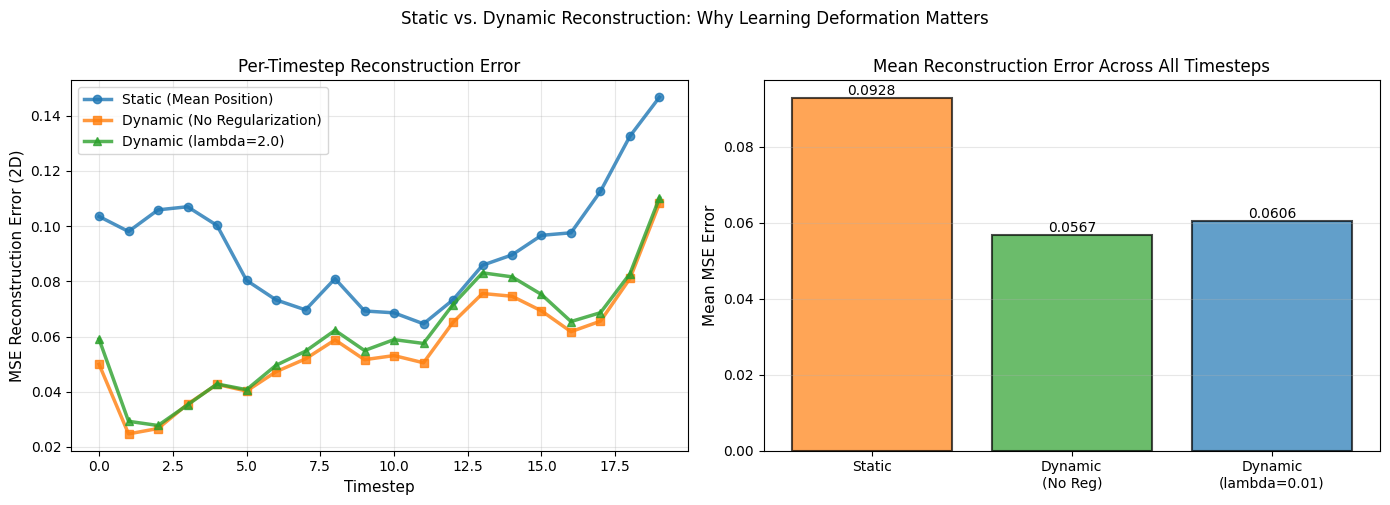

Dynamic reconstruction improves over static baseline by 38.9%.


In [17]:
# [Result 07]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
timesteps_range = np.arange(T)
ax.plot(timesteps_range, static_errors_per_timestep, 'o-', linewidth=2.5, 
        markersize=6, label='Static (Mean Position)', alpha=0.8)
ax.plot(timesteps_range, dynamic_errors_per_timestep, 's-', linewidth=2.5, 
        markersize=6, label='Dynamic (No Regularization)', alpha=0.8)
ax.plot(timesteps_range, dynamic_reg_errors_per_timestep, '^-', linewidth=2.5, 
        markersize=6, label=f'Dynamic (lambda={lambda_reg})', alpha=0.8)
ax.set_xlabel('Timestep', fontsize=11)
ax.set_ylabel('MSE Reconstruction Error (2D)', fontsize=11)
ax.set_title('Per-Timestep Reconstruction Error', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
methods = ['Static', 'Dynamic\n(No Reg)', 'Dynamic\n(lambda=0.01)']
means = [static_errors_per_timestep.mean(), 
         dynamic_errors_per_timestep.mean(),
         dynamic_reg_errors_per_timestep.mean()]
colors = ['#ff7f0e', '#2ca02c', '#1f77b4']
bars = ax.bar(methods, means, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Mean MSE Error', fontsize=11)
ax.set_title('Mean Reconstruction Error Across All Timesteps', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

for bar, mean in zip(bars, means):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Static vs. Dynamic Reconstruction: Why Learning Deformation Matters', 
             fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

improvement = (static_errors_per_timestep.mean() - dynamic_errors_per_timestep.mean()) / static_errors_per_timestep.mean() * 100
print(f'Dynamic reconstruction improves over static baseline by {improvement:.1f}%.')

**[Callout 05]**

## Engineering Callout: From Toy to Production

This notebook shows core 4DGS ideas. Production mapping:

| Toy | Production |
|-----|------------|
| NumPy MLP | CUDA MLP (3-4 layers, more hidden dims) |
| Manual ReLU gradients | Automatic differentiation (PyTorch) |
| Manual `zero_grad()` / accumulate | `optimizer.zero_grad()` + `loss.backward()` |
| Cosine LR decay (manual) | `torch.optim.lr_scheduler.CosineAnnealingLR` |
| Orthographic projection | Perspective projection with depth sorting |
| Per-Gaussian MSE on 2D | Photometric loss (L1) + SSIM on rendered images |
| Velocity regularization | Local rigidity priors (SC-GS) |
| Single observation | Multi-view images |
| 50 Gaussians, T=20 | 100k+ Gaussians, hundreds of frames |

**Key challenges omitted:**
1. Depth ordering and alpha-compositing
2. Appearance dynamics (color, opacity changes)
3. Camera motion and pose optimization
4. Gaussian initialization from SfM
5. View-dependent effects (specular, refraction)

**What transfers directly:** The gradient accumulation pattern, cosine scheduling, and the deformation-field architecture are identical in production. The only difference is scale and the rendering backend.

**[Text 09]**

## What's Next

### W16 NB 01: Video-to-3D with 4DGS
Take real video and reconstruct as 4D Gaussian scene. Learn multi-view camera poses, SfM initialization, appearance dynamics.

### W17: World Models and Dynamic Scenes
Combine 4DGS with world modeling. Predict future frames, plan trajectories, learn action-conditional deformation.

### Trend: [Production-Grade 4DGS: SC-GS and Beyond](https://artifocial.com/blog/4d-gaussian-frontier-2026-apr-17)
Rigidity constraints, appearance flows, mobile splatting, monocular challenges.

### Basics: [What is a 4D Gaussian?](https://artifocial.com/blog/4d-gaussian-splatting-explained-2026-apr-17)
Non-technical intro and comparisons to NeRF and mesh-based approaches.

---

### Recap: Key Takeaways

1. **4D Gaussians** = 3D Gaussians + time-dependent motion via shared deformation field
2. **Deformation MLP:** Small network predicting position offsets from canonical position and time
3. **Manual backprop:** ReLU gradients and chain rule are fundamental
4. **Orthographic projection:** Simplifies rendering, trades off depth ambiguity
5. **Temporal regularization:** Smooth motion improves generalization
6. **Dynamic > static:** Parameter-efficient scene modeling

### References
- Ren et al. (2023). [4D Gaussian Splatting for Real-Time Dynamic Scene Rendering](https://arxiv.org/abs/2310.08528). arXiv:2310.08528
- Liang et al. (2024). [SC-GS: Sparse-Controlled Gaussian Splatting for Editable Dynamic Scenes](https://arxiv.org/abs/2312.14937). arXiv:2312.14937
- Kerbl et al. (2023). [3D Gaussian Splatting for Real-Time Radiance Field Rendering](https://arxiv.org/abs/2308.04079). SIGGRAPH 2023
- Müller et al. (2022). [Instant Neural Graphics Primitives with a Multiresolution Hash Encoding](https://arxiv.org/abs/2201.05989). SIGGRAPH 2022

Questions? Feedback? Comment directly on our blog post or email us at info@artifocial.com.